# Step A — Multiple product detection

Scenes `e1..e5`, products `{0, 1, 11, 19, 24, 25, 26}`.

Pipeline: load → SIFT (detect + describe) → FLANN+Lowe match → RANSAC homography → Euclidian distance → bbox → report.

Solution for task A is divided in two; 
1. Single pair walkthrough for debug and testing
2. Compact sweep function across all scenes and model images

# Setup

In [432]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths and the Task A dataset
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tasks" else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
SCENES_DIR = PROJECT_ROOT / "scenes"
STEP_A_SCENES   = [f"e{i}.png" for i in range(1, 6)]
STEP_A_PRODUCTS = ["0", "1", "11", "19", "24", "25", "26"]


LOWE_RATIO = 0.6              # stricter = lower; 0.6 very strict, 0.75 permissive
RANSAC_REPROJ_THRESH = 5.0    # max reprojection error (px) for an inlier
MIN_GOOD_MATCHES = 40         # need this many post-Lowe matches to attempt RANSAC
MIN_INLIERS = 15              # need this many RANSAC inliers to accept the detection
COLOR_TOL = 50                # max BGR Euclidean distance between model and warped region

# BGR (OpenCV) -> RGB (matplotlib)
def show_bgr(bgr, title="", figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

# Single-pair walkthrough

Each pipeline stage shown on selected product and scene pair.

## 1. Load model and scene

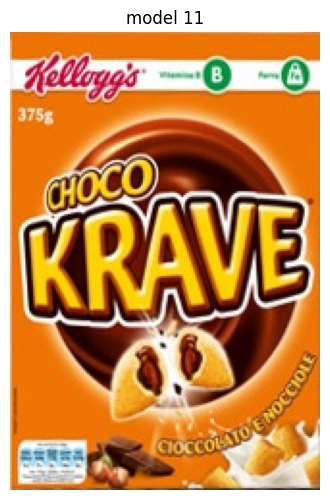

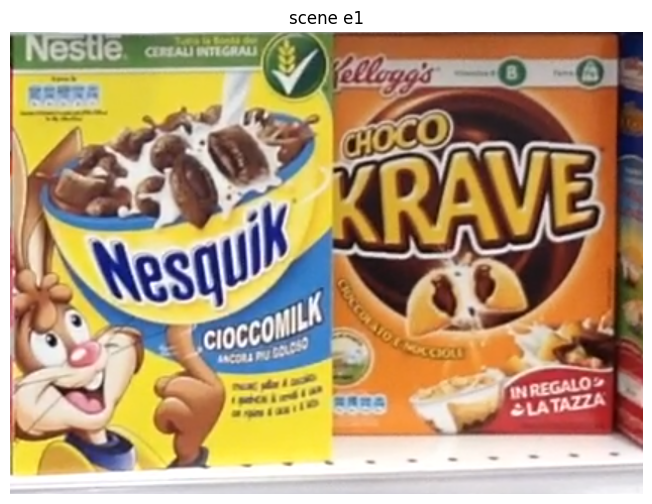

In [435]:
def load_pair(model_id, scene_id):
    model_bgr = cv2.imread(str(MODELS_DIR / f"{model_id}.jpg"), cv2.IMREAD_COLOR)
    scene_bgr = cv2.imread(str(SCENES_DIR / f"{scene_id}.png"), cv2.IMREAD_COLOR)
    model_gray = cv2.cvtColor(model_bgr, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)
    return model_bgr, scene_bgr, model_gray, scene_gray


model_id = "11"
scene_id = "e1"
model_bgr, scene_bgr, model_gray, scene_gray = load_pair(model_id, scene_id)

show_bgr(model_bgr, title=f"model {model_id}", figsize=(4, 6))
show_bgr(scene_bgr, title=f"scene {scene_id}")

## 2. SIFT — keypoints and descriptors

This cell applies SIFT keypoint detection and descriptor extraction to both the model and scene images. 
It then prints out the number of keypoints detected in each image, as well as details about the first keypoint in the model image and the shape and data type of the first descriptor. Finally, it visualizes the detected keypoints on both images using OpenCV's drawKeypoints function with the DRAW_RICH_KEYPOINTS flag, which draws circles scaled to the keypoint size and lines indicating orientation.


Keypoints (model): 356
Keypoints (scene): 2168
First model keypoint — loc: (2.3659064769744873, 197.0941162109375) scale: 1.8933229446411133 angle: 179.18191528320312
Descriptor shape: (128,) dtype: float32


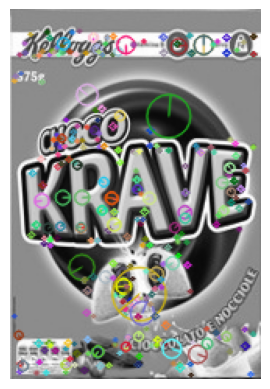

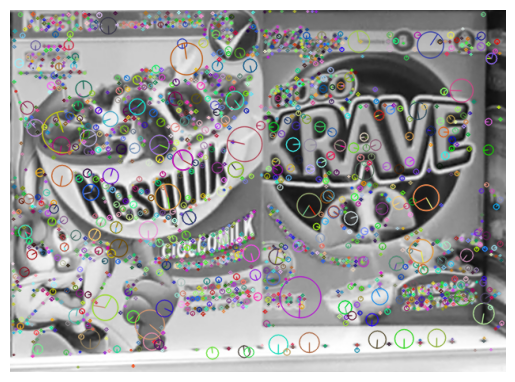

In [436]:
sift = cv2.SIFT_create()

def get_features(img_gray):
    return sift.detectAndCompute(img_gray, None)


kp_reference, des_reference = get_features(model_gray)
kp_target, des_target = get_features(scene_gray)

print("Keypoints (model):", len(kp_reference))
print("Keypoints (scene):", len(kp_target))
print("First model keypoint —",
      "loc:", kp_reference[0].pt,
      "scale:", kp_reference[0].size,
      "angle:", kp_reference[0].angle)
print("Descriptor shape:", des_reference[0].shape, "dtype:", des_reference[0].dtype)

# DRAW_RICH_KEYPOINTS draws a circle scaled to keypoint size + a line for orientation
img_m = cv2.drawKeypoints(model_gray, kp_reference, None,
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_s = cv2.drawKeypoints(scene_gray, kp_target, None,
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_m); plt.axis('off'); plt.show()
plt.imshow(img_s); plt.axis('off'); plt.show()

## 3. Feature matching — FLANN + Lowe's ratio test

The match_descriptors function applies Lowe's ratio test to filter out ambiguous matches. 
The procedure begins by using a FLANN-based matcher to find the two nearest neighbors for each descriptor in the model (des_m) against the descriptors in the scene (des_s).
The ratio test then compares the distance of the closest match (m) to the distance of the second-closest match (n). If the closest match is significantly better (i.e., its distance is less than a specified ratio times the distance of the second-closest match), it is considered a good match and retained. This helps to reduce false matches by ensuring that the best match is distinctly better than the next best alternative.

In [437]:
def match_descriptors(des_m, des_s, ratio=LOWE_RATIO):
    matcher = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = matcher.knnMatch(des_m, des_s, k=2)
    return [m for m, n in matches if m.distance < ratio * n.distance]


good_matches = match_descriptors(des_reference, des_target)
print(f"Total matches (1 per model descriptor): {len(des_reference)}")
print(f"Good matches after Lowe (ratio={LOWE_RATIO}):", len(good_matches))

Total matches (1 per model descriptor): 356
Good matches after Lowe (ratio=0.6): 93


## 4. Pose estimation — RANSAC homography

The find_homography function applies RANSAC to the matched keypoints and returns the homography matrix, inlier mask, and warped corners if successful; otherwise None.

In [438]:
def find_homography(kp_m, kp_s, good, model_shape):
    if len(good) < MIN_GOOD_MATCHES:
        return None
    src = np.float32([kp_m[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    M, mask = cv2.findHomography(src, dst, cv2.RANSAC, RANSAC_REPROJ_THRESH)
    if M is None or int(mask.sum()) < MIN_INLIERS:
        return None
    h, w = model_shape
    corners = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
    warped = cv2.perspectiveTransform(corners, M)
    return M, mask, warped


ransac_result = find_homography(kp_reference, kp_target, good_matches, model_gray.shape)

if ransac_result is None:
    print(f"Not enough matches/inliers for model {model_id} in scene {scene_id}.")
else:
    M, mask, warped = ransac_result
    print(f"RANSAC inliers: {int(mask.sum())}/{len(good_matches)}")

RANSAC inliers: 75/93


## 6. Colour verification — mean BGR + Euclidean distance

SIFT runs on grayscale, so it cannot tell apart products that share gradient structure but differ in colour (e.g. P1 blue Krave vs P11 orange Krave). We compute the mean BGR of the model and the mean BGR of the warped region in the scene, then take the Euclidean distance. Detections whose distance exceeds `COLOR_TOL` are rejected. This cell only computes the verdict; visualization happens in step 7 if all filters accepted.

The colour verification cell applies a mask to the scene's warped quadrilateral region and compares the mean BGR colour to that of the model, accepting if within COLOR_TOL.


In [439]:
def quad_mask(scene_shape, warped):
    m = np.zeros(scene_shape[:2], np.uint8)
    cv2.fillPoly(m, [np.int32(warped)], 255)
    return m

def mean_bgr(img, mask=None):
    return np.array(cv2.mean(img, mask=mask)[:3])

def color_distance(model_bgr, scene_bgr, warped):
    m_model = mean_bgr(model_bgr)
    m_scene = mean_bgr(scene_bgr, mask=quad_mask(scene_bgr.shape, warped))
    return float(np.linalg.norm(m_model - m_scene))


if ransac_result is None:
    color_ok = False
    print(f"Skipping colour check: no homography for model {model_id} in scene {scene_id}.")
else:
    dist = color_distance(model_bgr, scene_bgr, warped)
    color_ok = dist <= COLOR_TOL
    verdict = "ACCEPT" if color_ok else "REJECT"
    print(f"Colour distance: {dist:.2f}  [{verdict} at COLOR_TOL={COLOR_TOL}]")

Colour distance: 40.38  [ACCEPT at COLOR_TOL=50]


## 8. Visualization

The visualization cell applies the homography to draw the detected product's bounding box on the scene and visualizes the inlier matches.


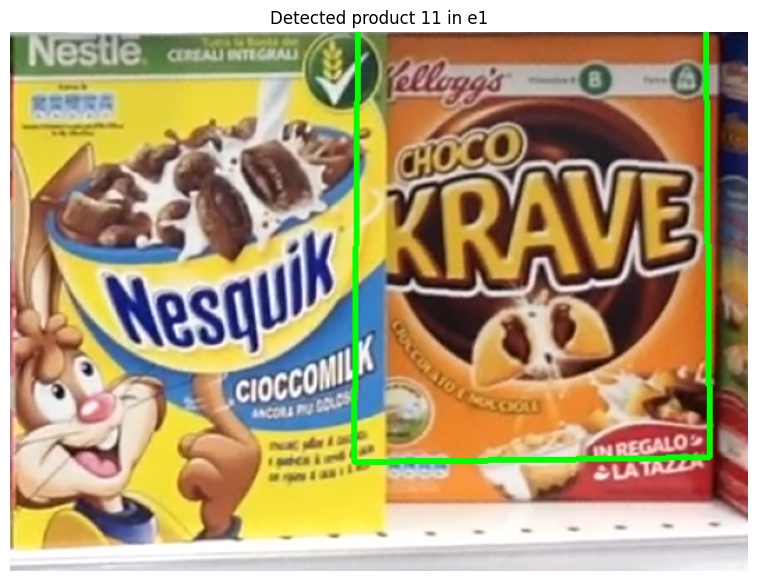

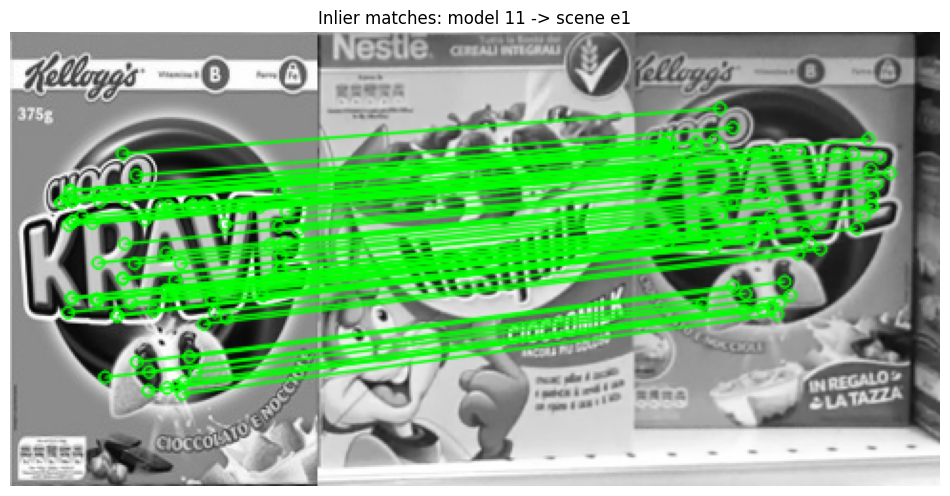

In [440]:
# The visualization applies the homography to draw the detected product's bounding box on the scene and visualizes the inlier matches; if RANSAC failed or the color check rejected this detection, it prints a message instead.

if ransac_result is None or not color_ok:
    print(f"No final visualization for model {model_id} in {scene_id}: one or more filters rejected this detection.")
else:
    M, mask, warped = ransac_result
    matches_mask = mask.ravel().tolist()

    # Bounding box on the scene
    scene_with_box = scene_bgr.copy()
    cv2.polylines(scene_with_box, [np.int32(warped)], True, (0, 255, 0), 3)
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(scene_with_box, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected product {model_id} in {scene_id}"); plt.axis('off'); plt.show()

    # Inlier matches visualization, resize scene so it shares the model's height
    scale = model_gray.shape[0] / scene_gray.shape[0]
    scene_small = cv2.resize(scene_gray, (0, 0), fx=scale, fy=scale)
    kp_target_small = [cv2.KeyPoint(kp.pt[0]*scale, kp.pt[1]*scale, kp.size*scale, kp.angle)
                       for kp in kp_target]

    draw_params = dict(matchColor=(0, 255, 0), singlePointColor=None,
                       matchesMask=matches_mask, flags=2)
    img_matches = cv2.drawMatches(model_gray, kp_reference, scene_small, kp_target_small,
                                  good_matches, None, **draw_params)
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(f"Inlier matches: model {model_id} -> scene {scene_id}"); plt.axis('off'); plt.show()

# Multi-pair sweep — iterative masking

This final section runs the full detection pipeline for all products in each scene, using iterative masking to handle multiple instances and similar products. It collects detections, draws bounding boxes on the original scene, and prints the results.



Processing scene: e1


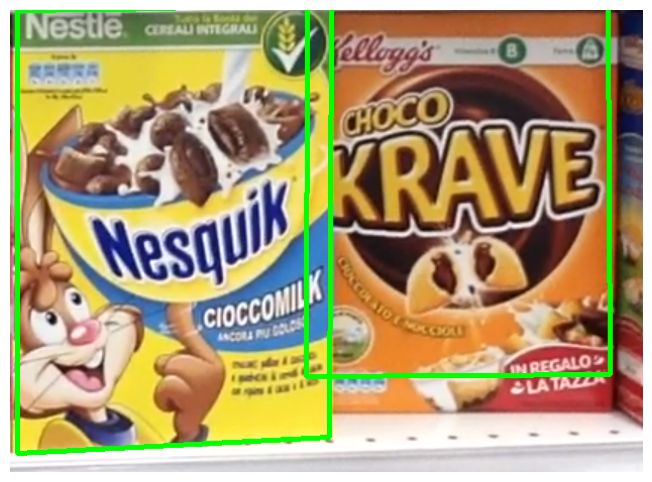

Product 0: 1 instance(s) found
  Instance 1 {position: (7, -4), width: 311px, height: 443px}
Product 1: 0 instance(s) found
Product 11: 1 instance(s) found
  Instance 1 {position: (293, -27), width: 301px, height: 390px}
Product 19: 0 instance(s) found
Product 24: 0 instance(s) found
Product 25: 0 instance(s) found
Product 26: 0 instance(s) found

Processing scene: e2


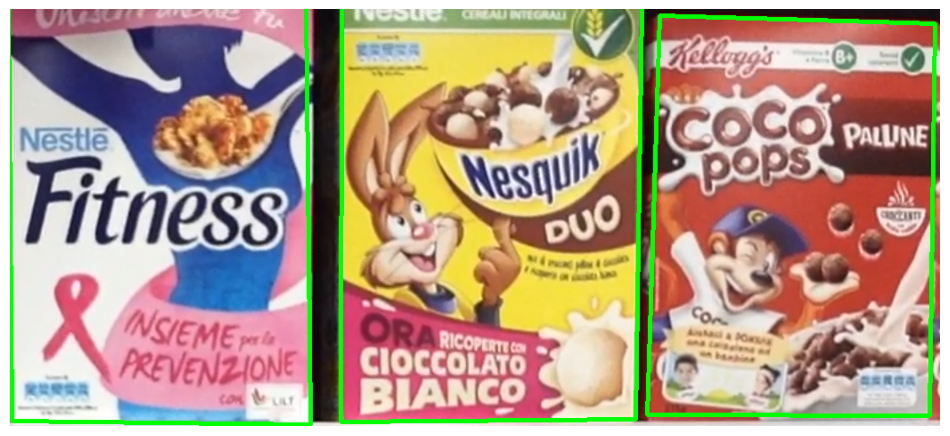

Product 0: 0 instance(s) found
Product 1: 0 instance(s) found
Product 11: 0 instance(s) found
Product 19: 0 instance(s) found
Product 24: 1 instance(s) found
  Instance 1 {position: (-2, -28), width: 339px, height: 494px}
Product 25: 1 instance(s) found
  Instance 1 {position: (715, 7), width: 323px, height: 449px}
Product 26: 1 instance(s) found
  Instance 1 {position: (371, -25), width: 338px, height: 488px}

Processing scene: e3


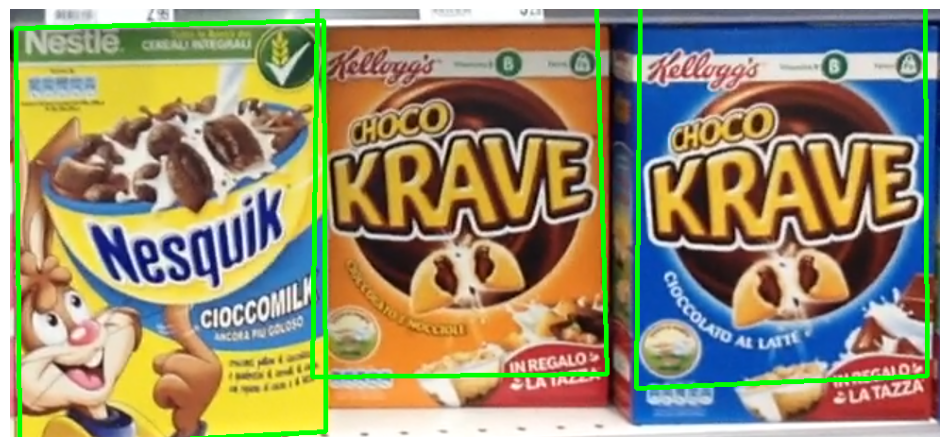

Product 0: 1 instance(s) found
  Instance 1 {position: (6, 12), width: 328px, height: 452px}
Product 1: 1 instance(s) found
  Instance 1 {position: (663, -9), width: 308px, height: 410px}
Product 11: 1 instance(s) found
  Instance 1 {position: (320, -6), width: 312px, height: 395px}
Product 19: 0 instance(s) found
Product 24: 0 instance(s) found
Product 25: 0 instance(s) found
Product 26: 0 instance(s) found

Processing scene: e4


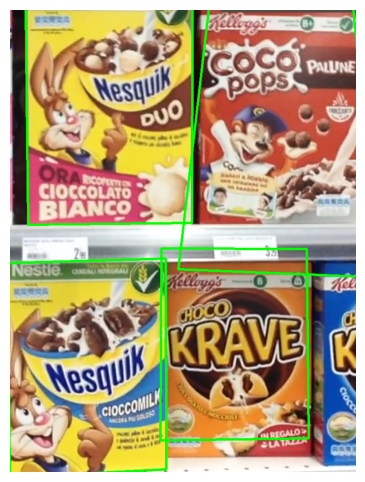

Product 0: 1 instance(s) found
  Instance 1 {position: (-5, 514), width: 327px, height: 453px}
Product 1: 0 instance(s) found
Product 11: 1 instance(s) found
  Instance 1 {position: (310, 493), width: 306px, height: 397px}
Product 19: 0 instance(s) found
Product 24: 0 instance(s) found
Product 25: 1 instance(s) found
  Instance 1 {position: (347, -14), width: 411px, height: 566px}
Product 26: 1 instance(s) found
  Instance 1 {position: (32, -52), width: 344px, height: 496px}

Processing scene: e5


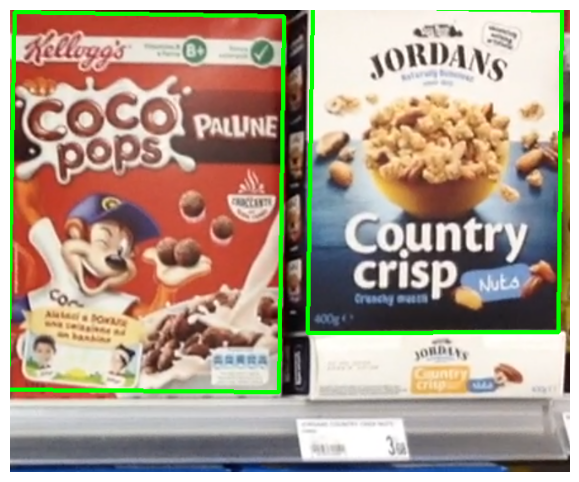

Product 0: 0 instance(s) found
Product 1: 0 instance(s) found
Product 11: 0 instance(s) found
Product 19: 1 instance(s) found
  Instance 1 {position: (352, -4), width: 301px, height: 386px}
Product 24: 0 instance(s) found
Product 25: 1 instance(s) found
  Instance 1 {position: (-3, 2), width: 327px, height: 450px}
Product 26: 0 instance(s) found


In [ ]:
model_features = {}
for pid in STEP_A_PRODUCTS: # Pre-compute model features once (same models reused for every scene).
    m_bgr = cv2.imread(str(MODELS_DIR / f"{pid}.jpg"), cv2.IMREAD_COLOR)
    m_gray = cv2.cvtColor(m_bgr, cv2.COLOR_BGR2GRAY)
    kp_m, des_m = get_features(m_gray)
    model_features[pid] = {"bgr": m_bgr, "gray": m_gray, "kp": kp_m, "des": des_m}

# The main loop processes each scene, 
# applying the detection pipeline iteratively to find multiple instances of products. 
for scene_name in STEP_A_SCENES: 
    scene_id = scene_name.replace(".png", "")
    scene_bgr = cv2.imread(str(SCENES_DIR / scene_name), cv2.IMREAD_COLOR)
    scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)

    remaining_bgr  = scene_bgr.copy()
    remaining_gray = scene_gray.copy()
    remaining_pids = set(STEP_A_PRODUCTS)
    detections = []  # list of (pid, warped)

    while remaining_pids: # Loop until no more products to try or no more detections
        kp_s, des_s = get_features(remaining_gray)

        best = None  # (pid, inliers, warped)
        for pid in remaining_pids: 
            m = model_features[pid]
            good = match_descriptors(m["des"], des_s)
            ransac_result = find_homography(m["kp"], kp_s, good, m["gray"].shape)
            if ransac_result is None:
                continue
            _, mask, warped = ransac_result

            if color_distance(m["bgr"], scene_bgr, warped) > COLOR_TOL:
                continue

            inliers = int(mask.sum()) 
            if best is None or inliers > best[1]:
                best = (pid, inliers, warped)

        if best is None:
            break
        
        # If the best detection is found, it gets added to the detections list, 
        # and the corresponding region in the remaining scene is blacked out to 
        # prevent it being detected again in subsequent iterations.
        pid, _, warped = best
        detections.append((pid, warped))
        cv2.fillPoly(remaining_bgr,  [np.int32(warped)], (0, 0, 0))
        cv2.fillPoly(remaining_gray, [np.int32(warped)], 0)
        remaining_pids.discard(pid)

    # Draw all winning detections on the original scene
    scene_with_boxes = scene_bgr.copy()
    instances = {pid: [] for pid in STEP_A_PRODUCTS}
    for pid, warped in detections:
        cv2.polylines(scene_with_boxes, [np.int32(warped)], True, (0, 255, 0), 3)
        xs, ys = warped[:, 0, 0], warped[:, 0, 1]
        x_min, x_max = int(xs.min()), int(xs.max())
        y_min, y_max = int(ys.min()), int(ys.max())
        instances[pid].append({
            "position": (x_min, y_min),
            "width": x_max - x_min,
            "height": y_max - y_min,
        })

    # Prints the instances found for each product in this scene, along with their positions and sizes.
    print(f"\n\033[1mProcessing scene: {scene_id}\033[0m")
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(scene_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    for pid in STEP_A_PRODUCTS:
        n = len(instances[pid])
        print(f"Product {pid}: {n} instance(s) found")
        for i, inst in enumerate(instances[pid], 1):
            print(f"  Instance {i} {{position: {inst['position']}, "
                  f"width: {inst['width']}px, height: {inst['height']}px}}")